인코더에 입력된 각 셀 값을 하나씩 뒤로 보내다가, 맨 마지막 셀이 이 값을 디코더에 전달한다. 이 마지막 셀에 담긴 값에 전체 문장이 함축되어 있는데 이를 문맥 벡터(context vector)라고 한다.

어텐션의 원리는 다음과 같다.  
먼저 인코도와 디코더 사이에 층이 하나 생긴다. 새로 삽입된 층에는 각 셀로부터 계산된 스코어들이 모인다. 이 스코어를 이용해 소프트맥스 함수를 사용해서 어텐션 가중치를 만든다. 이 가중치를 이용해 입력 값 중 어떤 셀을 중점적으로 볼지 결정한다. 매 출력마다 모든 입력 값을 두루 활용하는 것이 어텐션이다.

어텐션을 실행하기 위해 어텐션(attention) 라이브러리가 필요하다. 코랩에서는 다음과 같이 어텐션 라이브러리를 설치한다.

In [1]:
!pip install attention

모델에 Attention() 함수가 들어갈 레이어를 다음과 같이 추가한다.

In [2]:
from tensorflow.keras.models import Sequential
from attention import Attention

model = Sequential()
model.add(Attention())

실습| 어텐션을 사용한 신경망

17464789/17464789 [==============================] - 0s 0us/step
Epoch 1/100
625/625 [==============================] - 1233s 2s/step - loss: 0.3756 - accuracy: 0.8270 - val_loss: 0.2768 - val_accuracy: 0.8861
Epoch 2/100
625/625 [==============================] - 1234s 2s/step - loss: 0.2230 - accuracy: 0.9134 - val_loss: 0.2869 - val_accuracy: 0.8906
Epoch 3/100
625/625 [==============================] - 1217s 2s/step - loss: 0.1589 - accuracy: 0.9387 - val_loss: 0.3084 - val_accuracy: 0.8851
Epoch 4/100
782/782 [==============================] - 241s 307ms/step - loss: 0.3793 - accuracy: 0.8766

 Test Accuracy: 0.8766


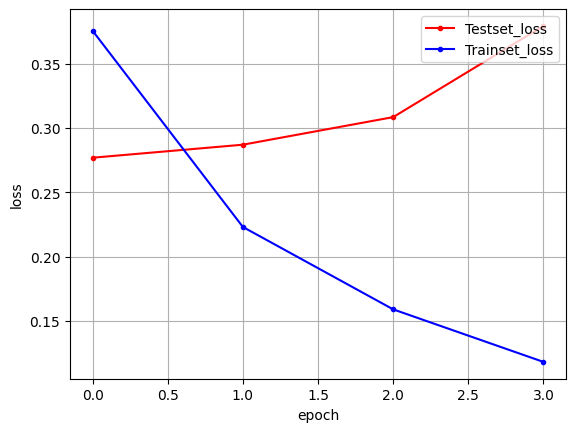

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Embedding, LSTM, Conv1D, MaxPooling1D
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.callbacks import EarlyStopping
from attention import Attention

import numpy as np
import matplotlib.pyplot as plt

# 데이터를 불러와 학습셋, 테스트셋으로 나눈다.
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=5000)

# 단어의 수를 맞춘다.
X_train = sequence.pad_sequences(X_train, maxlen=500)
X_test = sequence.pad_sequences(X_test, maxlen=500)

# 모델의 구조를 설정한다.
model = Sequential()
model.add(Embedding(5000, 500))
model.add(Dropout(0.5))
model.add(LSTM(64, return_sequences=True))
model.add(Attention())
model.add(Dropout(0.5))
model.add(Dense(1))
model.add(Activation('sigmoid'))

# 모델의 실행 옵션을 정한다.
model.compile(loss='binary_crossentropy', optimizer='adam',
              metrics=['accuracy'])

# 학습의 조기 중단을 설정한다.
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=3)

# 모델을 실행한다.
history = model.fit(X_train, y_train, batch_size=40, epochs=100,
                    validation_data=(X_test, y_test), callbacks=[early_stopping_callback])

# 테스트 정확도를 출력한다.
print("\n Test Accuracy: %.4f" % (model.evaluate(X_test, y_test)[1]))

# 검증셋과 학습셋의 오차를 저장한다.
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

# 그래프로 표현해 본다.
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c='red', label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c='blue', label='Trainset_loss')

# 그래프에 그리드를 주고 레이블을 표시한다.
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()